# CardioCare 1. EDA


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.data_loader import binarize_target, load_raw_data
from src.preprocessing import (
    CONTINUOUS_FEATURES,
    FEATURE_COLUMNS,
    build_preprocessing_pipeline,
)

sns.set_theme(style="whitegrid")

In [3]:
raw = load_raw_data(ROOT / "data")
df = binarize_target(raw)

print("head():")
display(df[FEATURE_COLUMNS + ["target", "source"]].head())
print("\ninfo():")
df[FEATURE_COLUMNS + ["target"]].info()
print("\ndescribe():")
display(df[FEATURE_COLUMNS].describe())

head():


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal,target,source
0,63.0,145.0,233.0,150.0,2.3,1.0,1.0,1.0,2.0,0.0,3.0,0.0,6.0,0,cleveland
1,67.0,160.0,286.0,108.0,1.5,1.0,4.0,0.0,2.0,1.0,2.0,3.0,3.0,1,cleveland
2,67.0,120.0,229.0,129.0,2.6,1.0,4.0,0.0,2.0,1.0,2.0,2.0,7.0,1,cleveland
3,37.0,130.0,250.0,187.0,3.5,1.0,3.0,0.0,0.0,0.0,3.0,0.0,3.0,0,cleveland
4,41.0,130.0,204.0,172.0,1.4,0.0,2.0,0.0,2.0,0.0,1.0,0.0,3.0,0,cleveland



info():
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   trestbps  861 non-null    float64
 2   chol      890 non-null    float64
 3   thalach   865 non-null    float64
 4   oldpeak   858 non-null    float64
 5   sex       920 non-null    float64
 6   cp        920 non-null    float64
 7   fbs       830 non-null    float64
 8   restecg   918 non-null    float64
 9   exang     865 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  target    920 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 100.8 KB

describe():


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal
count,920.000000,861.000000,890.000000,865.000000,858.000000,920.000000,920.000000,830.000000,918.000000,865.000000,611.000000,309.000000,434.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.789130,3.250000,0.166265,0.604575,0.389595,1.770867,0.676375,5.087558
std,9.424685,19.066070,110.780810,25.926276,1.091226,0.408148,0.930969,0.372543,0.805827,0.487941,0.619256,0.935653,1.919075
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,1.000000,4.000000,0.000000,0.000000,0.000000,2.000000,0.000000,6.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,4.000000,0.000000,1.000000,1.000000,2.000000,1.000000,7.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,1.000000,4.000000,1.000000,2.000000,1.000000,3.000000,3.000000,7.000000


타깃 클래스 분포 (normalize=True):
target
1    0.553261
0    0.446739
Name: proportion, dtype: float64


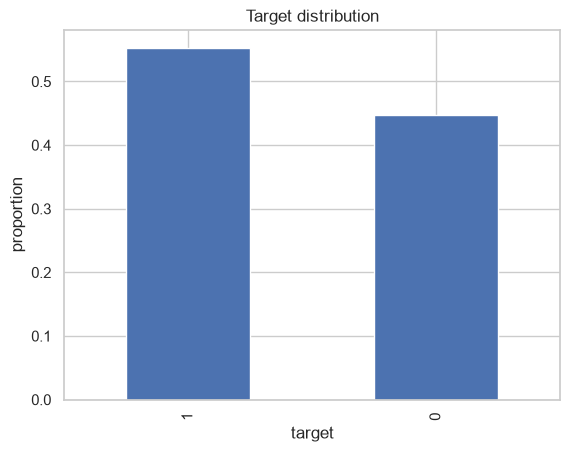

In [4]:
target_dist = df["target"].value_counts(normalize=True)
print("타깃 클래스 분포 (normalize=True):")
print(target_dist)

target_dist.plot(kind="bar", title="Target distribution")
plt.ylabel("proportion")
plt.show()

결과 해석: 생각보다 심각한 불균형을 보여주진 않는다. 하지만 환자를 찾는데 있어 정밀도보단 재현율을 높여 실제 병이 있음에도 정상이라고 표기되는 상황이 훨씬 심각한 문제를 초래하기 떄문에 모델은 기본적으로 재현율을 올리기 위한 방법들을 채용해야한다. 

In [5]:
feature_df = df[FEATURE_COLUMNS]
missing_by_col = feature_df.isna().sum()
missing_total = feature_df.isna().sum().sum()
print("열별 결측값:")
print(missing_by_col[missing_by_col > 0])
print(f"\n전체 결측값 개수: {missing_total}")

열별 결측값:
trestbps     59
chol         30
thalach      55
oldpeak      62
fbs          90
restecg       2
exang        55
slope       309
ca          611
thal        486
dtype: int64

전체 결측값 개수: 1759


C:\Users\dhdbs\AppData\Local\Temp\ipykernel_31832\3009031040.py:6: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dhdbs\AppData\Local\Temp\ipykernel_31832\3009031040.py:6: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dhdbs\AppData\Local\Temp\ipykernel_31832\3009031040.py:6: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dhdbs\AppData\Local\Temp\ipykernel_31832\3009031040.py:6: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dhdbs\AppData\Local\Temp\ipykernel_31832\3009031040.py:6: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dhdbs\AppData\Local\Temp\ipykernel_31832\3009031040.py:6: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  plt.tight_la

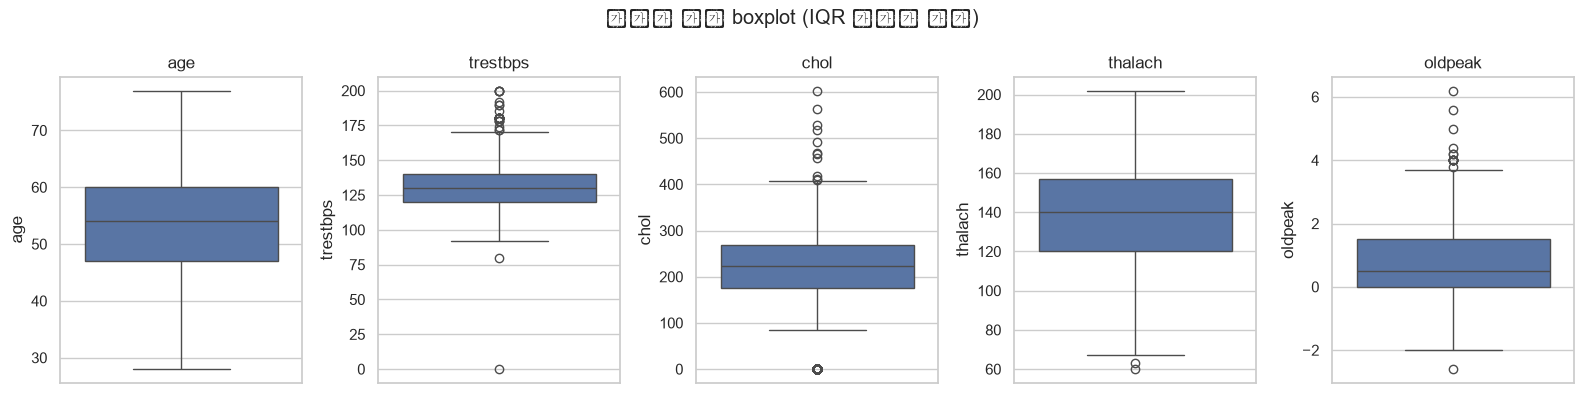

In [6]:
fig, axes = plt.subplots(1, len(CONTINUOUS_FEATURES), figsize=(16, 4))
for ax, col in zip(axes, CONTINUOUS_FEATURES):
    sns.boxplot(y=feature_df[col].dropna(), ax=ax)
    ax.set_title(col)
plt.suptitle("연속형 특성 boxplot (IQR 이상치 탐색)")
plt.tight_layout()
plt.show()

In [7]:
pipeline = build_preprocessing_pipeline()
X = feature_df
y = df["target"]
X_train = X.sample(frac=0.8, random_state=42)
pipeline.fit(X_train)
X_clean = pipeline.transform(X)

print("전처리 후 shape:", X_clean.shape)
print("중복 행 수 (전처리 전):", X.duplicated().sum())

전처리 후 shape: (920, 13)
중복 행 수 (전처리 전): 2


## EDA가 무엇을 알려 주었으며, 그에 따라 전처리에서 무엇을 어떻게 바꾸었는가?
1. 결측값: `-9` 마커 및 일부 컬럼 결측이 확인되어, 컬럼 삭제 대신 중앙값 대치를 선택했습니다. 
2. 이상치: `chol`, `trestbps`, `oldpeak` 등에서 boxplot 꼬리가 길어 IQR 기반클리핑을 적용했습니다. 정보가 많지 않기 때문에 데이터 하나가 삭제될 때마다 큰 손해라고 생각했습니다. 
3. 빈 컬럼/중복: 결측만 있는 컬럼은 제거하고, 중복 레코드는 학습 전 `prepare_dataset()` 단계에서 제거했습니다.
4. 누수 방지: 스케일링과 특성 선택·IQR 경계는 모두 train split 이후 fit 하도록 `src/train.py` 파이프라인에 분리했습니다.